In [2]:
from pathlib import Path
import sys
import pickle
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
from hydrax.utils.files import get_data_path
from scipy.ndimage import uniform_filter1d  # Or use np.convolve

def rotmat(yaw: float) -> np.ndarray:
    c, s = math.cos(yaw), math.sin(yaw)
    return np.array([[c, -s],
                     [s,  c]])
    
def rectangle_corners(center_xy, width, height, yaw):
    cx, cy = center_xy
    R = rotmat(yaw)
    hw, hh = width / 2.0, height / 2.0
    local = np.array([
        [-hw, -hh],
        [ hw, -hh],
        [ hw,  hh],
        [-hw,  hh],
    ])
    world = (local @ R.T) + np.array([cx, cy])
    return world

def t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h):
    stem_center_local = np.array([0.0, -head_h / 2.0])
    head_center_local = np.array([0.0,  stem_h / 2.0])

    stem_center_world = (stem_center_local @ rotmat(yaw).T) + np.array([x, y]) + np.array([0.0425, 0.0])
    head_center_world = (head_center_local @ rotmat(yaw).T) + np.array([x, y]) + np.array([0.0425, 0.0])

    stem_poly = rectangle_corners(stem_center_world, stem_w, stem_h, yaw)
    head_poly = rectangle_corners(head_center_world, head_w, head_h, yaw)
    return stem_poly, head_poly

def plot_action_space(ax, xmin, xmax, ymin, ymax, show_grid=False, grid_dx=0.25):
    ax.add_patch(Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=1.5))
    if show_grid and grid_dx > 0:
        xv = np.arange(math.ceil(xmin / grid_dx) * grid_dx, xmax + 1e-9, grid_dx)
        yv = np.arange(math.ceil(ymin / grid_dx) * grid_dx, ymax + 1e-9, grid_dx)
        for xx in xv:
            ax.plot([xx, xx], [ymin, ymax], linewidth=0.4)
        for yy in yv:
            ax.plot([xmin, xmax], [yy, yy], linewidth=0.4)

def draw_t(ax, x, y, yaw_deg, stem_w, stem_h, head_w, head_h,
           face_alpha=0.4, edge_width=0.0, facecolor=None, edgecolor=None, label=None):
    yaw = yaw_deg#math.radians(yaw_deg)
    stem_poly, head_poly = t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h)
    poly_kwargs = dict(closed=True, alpha=face_alpha)
    if facecolor is not None:
        poly_kwargs["facecolor"] = facecolor
    if edgecolor is not None:
        poly_kwargs["edgecolor"] = edgecolor

    stem_patch = Polygon(stem_poly, **poly_kwargs, linewidth=edge_width)
    head_patch = Polygon(head_poly, **poly_kwargs, linewidth=edge_width)
    ax.add_patch(stem_patch)
    ax.add_patch(head_patch)
    if label:
        ax.text(x, y, label, ha="center", va="center", fontsize=10)
    return np.vstack([stem_poly, head_poly])

def quat_to_yaw_manual(qx, qy, qz, qw):
    # Normalize
    norm = np.sqrt(qx**2 + qy**2 + qz**2 + qw**2)
    qw /= norm; qx /= norm; qy /= norm; qz /= norm
    
    sin_yaw_2 = 2 * (qw * qz + qx * qy)
    cos_yaw_2 = 1 - 2 * (qy**2 + qz**2)
    yaw = np.arctan2(sin_yaw_2, cos_yaw_2)
    return np.rad2deg(yaw)

def subsample_to_target(data, target_steps=300):
    """Uniformly subsample data to target_steps if longer."""
    if len(data) <= target_steps:
        return data
    indices = np.linspace(0, len(data) - 1, target_steps, dtype=int)
    return [data[i] for i in indices]

import seaborn as sns
import pandas as pd
sns.set(font_scale=1.7, rc={'font.size':17, 'font.family':'serif'})

In [3]:
seeds = [100, 101, 102]
# seeds = [100]

colors = ['C0', 'C1', 'C2']

# Collect all data into long-form DataFrame
df_list = []
final_T = {}
domain_weights = {}
poses = {}
full_poses = {}
ee_pos = {}

for version in ["exp"]:
    final_T[version] = []
    domain_weights[version] = {}
    poses[version] = {}
    full_poses[version] = {}
    ee_pos[version] = {}
    for seed in seeds:
        # path = get_data_path() / "sim-real-dr-robust" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
        path = get_data_path() / "dr_real_margin_shifting" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
        
        with open(path, "rb") as f:
            data = pickle.load(f)
        
        data = subsample_to_target(data, target_steps=150)  
        
        # final T
        quat = np.array(data[-1]['object_quat']) # is w x y z
        # quat to yaw
        jaw = quat_to_yaw_manual(quat[1], quat[2], quat[3], quat[0]) # needs x y z w
        x = data[-1]['object_pos'][0]
        y = data[-1]['object_pos'][1]

        final_T[version].append(np.concatenate((np.array([x, y]), np.array([jaw]))))
        domain_weights[version][seed] = [data[i]['domain_weights'] for i in range(len(data))]

        poses[version][seed] = []
        full_poses[version][seed] = []
        ee_pos[version][seed] = []
        for timestep in data:
            jaw = quat_to_yaw_manual(timestep['object_quat'][3], timestep['object_quat'][0], timestep['object_quat'][1], timestep['object_quat'][2])
            x = timestep['object_pos'][0]
            y = timestep['object_pos'][1]
            poses[version][seed].append(np.array([x, y, jaw]))
            full_poses[version][seed].append(np.array(timestep['object_pos'] + timestep['object_quat']))
            ee_pos[version][seed].append(np.array(timestep['ee_pos']))
        
        ee_pos[version][seed] = [data[i]['ee_pos'] for i in range(len(data))]

        timestep = np.arange(min(400, len(data)))
        df_list.append(pd.DataFrame({
            'timestep': timestep,
            'terminal_error': [d["terminal_error"] for d in data[:400]],
            'version': version,
            'seed': seed
        }))


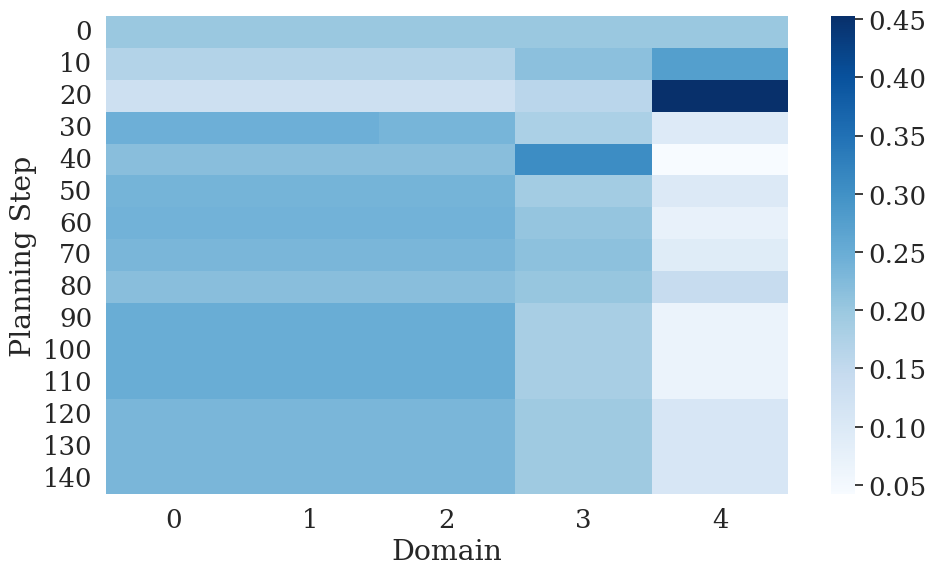

In [4]:
weights = domain_weights['exp'][101]  # shape (timesteps, domains)
weights = np.array(weights)[::10]  # subsample for better visualization

# heatmap table of domain weights over time
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(weights, ax=ax, cmap='Blues')
ax.set_xlabel('Domain')
ax.set_ylabel('Planning Step')
ax.set_yticklabels(np.arange(0, weights.shape[0]*10, 10))

plt.tight_layout()
plt.show()

(30, 3)


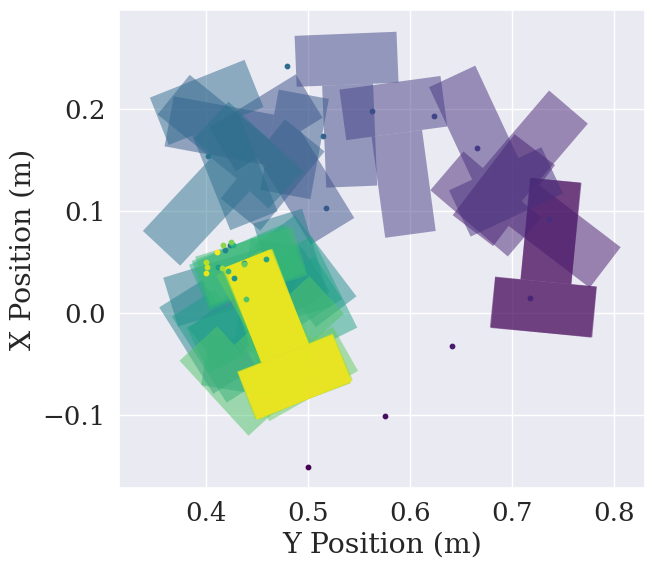

In [21]:
incr = 5
seed_poses = poses['exp'][100]  
seed_poses = np.array(seed_poses)[::incr] 
print(seed_poses.shape)

seed_ee_pos = ee_pos['exp'][100] 
seed_ee_pos = np.array(seed_ee_pos)[::incr] 
labels = [f'{i*incr}' for i in range(len(seed_ee_pos))]

# Create colormap
cmap = plt.cm.viridis
colors_timestep = cmap(np.linspace(0, 1, len(seed_poses)))

# plot ee_pos at timesteps as above
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(seed_ee_pos)):
    ax.scatter(seed_ee_pos[i, 0], seed_ee_pos[i, 1], color=colors_timestep[i], s=10, zorder=10)
    # ax.annotate(labels[i], (-seed_ee_pos[i, 1], seed_ee_pos[i, 0]), fontsize=5)

# plot Ts
for i in range(len(seed_poses)):
    x = seed_poses[i, 0]
    y = seed_poses[i, 1]
    jaw = seed_poses[i, 2] #+ np.pi/5
    draw_t(ax, x, y, jaw, stem_w=0.05, stem_h=0.1, head_w=0.1, head_h=0.05,
           face_alpha=0.5, edge_width=0.0, facecolor=colors_timestep[i], edgecolor=colors_timestep[i])

# ax.set_ylim(0.2, 0.8)
# ax.set_xlim(-0.3, 0.3)
ax.set_aspect('equal')
plt.xlabel('Y Position (m)')
plt.ylabel('X Position (m)')
plt.tight_layout()
plt.show()

(148, 7)


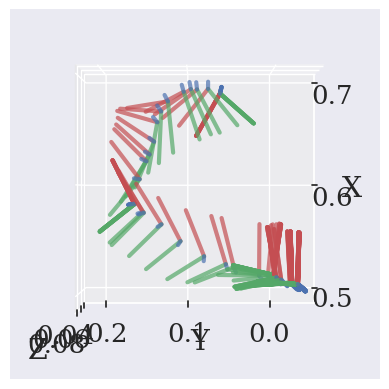

In [18]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as R

full = np.array(full_poses['exp'][101])
print(full.shape)
def plot_quat_frames(poses, scale=0.05, ax=None):
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    
    positions = poses[:, :3]  # x, y, z
    quats = poses[:, 3:]      # qw, qx, qy, qz
    
    # XYZ directions in local frame
    dirs = np.eye(3)  # Better: identity matrix
    
    for i in range(len(poses)):
        rot = R.from_quat(quats[i, [1,2,3,0]])  # qx,qy,qz,qw
        world_dirs = (rot.apply(dirs) * scale).T  # (3,3)
        
        origin = positions[i]  # (3,)
        ends = origin[None, :] + world_dirs  # (3,3)
        
        # Plot: red=X, green=Y, blue=Z
        colors = ['r', 'g', 'b']
        for j in range(3):
            ax.plot([origin[0], ends[j,0]], [origin[1], ends[j,1]], 
                    [origin[2], ends[j,2]], c=colors[j], lw=3, alpha=0.7)
    
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.view_init(elev=90, azim=180)
    # ax.set_xlim(0.4, 0.8); ax.set_ylim(-0.3, 0.3); ax.set_zlim(-0.3, 0.3)
    ax.set_aspect('auto')
    plt.show()

plot_quat_frames(full)